In [ ]:
import numpy as np
from plyfile import PlyData, PlyElement

PATH = 'Poison-3DGS/kitchen_3dgs.ply'

ROTACION_POS_1 = [5.92, 2.33, 2.38, -1.0, 0.6, -1.7] #Rot x, Rot y, Rot z, Pos x, Pos y, Pos z
ROTACION_POS_2 = [0.0, 1.17, 2.96, 1.4, 1.4, -2.4]
ROTACION_POS_3 = [2.42, 0.67, 5.21, -1.4, 1.4, 0.0]

In [9]:
plydata = PlyData.read(PATH)
vert = plydata["vertex"].data
x = vert["x"]
print(x, len(x))

[-1.2634239 -1.4072487 -1.4177015 ...  4.8033347  4.7191677  5.0757604] 1196078


In [6]:
print(plydata)

ply
format binary_little_endian 1.0
element vertex 1196078
property float x
property float y
property float z
property float nx
property float ny
property float nz
property float f_dc_0
property float f_dc_1
property float f_dc_2
property float f_rest_0
property float f_rest_1
property float f_rest_2
property float f_rest_3
property float f_rest_4
property float f_rest_5
property float f_rest_6
property float f_rest_7
property float f_rest_8
property float f_rest_9
property float f_rest_10
property float f_rest_11
property float f_rest_12
property float f_rest_13
property float f_rest_14
property float f_rest_15
property float f_rest_16
property float f_rest_17
property float f_rest_18
property float f_rest_19
property float f_rest_20
property float f_rest_21
property float f_rest_22
property float f_rest_23
property float f_rest_24
property float f_rest_25
property float f_rest_26
property float f_rest_27
property float f_rest_28
property float f_rest_29
property float f_rest_30
prope

| Canal de Color vs Grado | Grado 0 (Base Difusa) | Grado 1 (3 Coeficientes por canal) | Grado 2 (5 Coeficientes por canal) | Grado 3 (7 Coeficientes por canal) |
| :--- | :--- | :--- | :--- | :--- |
| **Rojo (R)** | `f_dc_0` | `f_rest_0`, `f_rest_3`, `f_rest_6` | `f_rest_9`, `f_rest_12`, `f_rest_15`, `f_rest_18`, `f_rest_21` | `f_rest_24`, `f_rest_27`, `f_rest_30`, `f_rest_33`, `f_rest_36`, `f_rest_39`, `f_rest_42` |
| **Verde (G)** | `f_dc_1` | `f_rest_1`, `f_rest_4`, `f_rest_7` | `f_rest_10`, `f_rest_13`, `f_rest_16`, `f_rest_19`, `f_rest_22` | `f_rest_25`, `f_rest_28`, `f_rest_31`, `f_rest_34`, `f_rest_37`, `f_rest_40`, `f_rest_43` |
| **Azul (B)** | `f_dc_2` | `f_rest_2`, `f_rest_5`, `f_rest_8` | `f_rest_11`, `f_rest_14`, `f_rest_17`, `f_rest_20`, `f_rest_23` | `f_rest_26`, `f_rest_29`, `f_rest_32`, `f_rest_35`, `f_rest_38`, `f_rest_41`, `f_rest_44` |



In [ ]:
def calc_energy(*coeffs):
    return np.sum(np.stack(coeffs, axis=0)**2, axis=0) # Norma de coef correspondientes || coeffs ||

### Grado 0

In [11]:
E0 = calc_energy(
    vert["f_dc_0"],
    vert["f_dc_1"],
    vert["f_dc_2"]
)

### Grado 1

In [14]:
E1 = calc_energy(
    *[vert[f"f_rest_{i}"] for i in range(0, 9)]
)

### Grado 2

In [13]:
E2 = calc_energy(
    *[vert[f"f_rest_{i}"] for i in range(9, 24)]
)

### Grado 3

In [15]:
E3 = calc_energy(
    *[vert[f"f_rest_{i}"] for i in range(24, 45)]
)

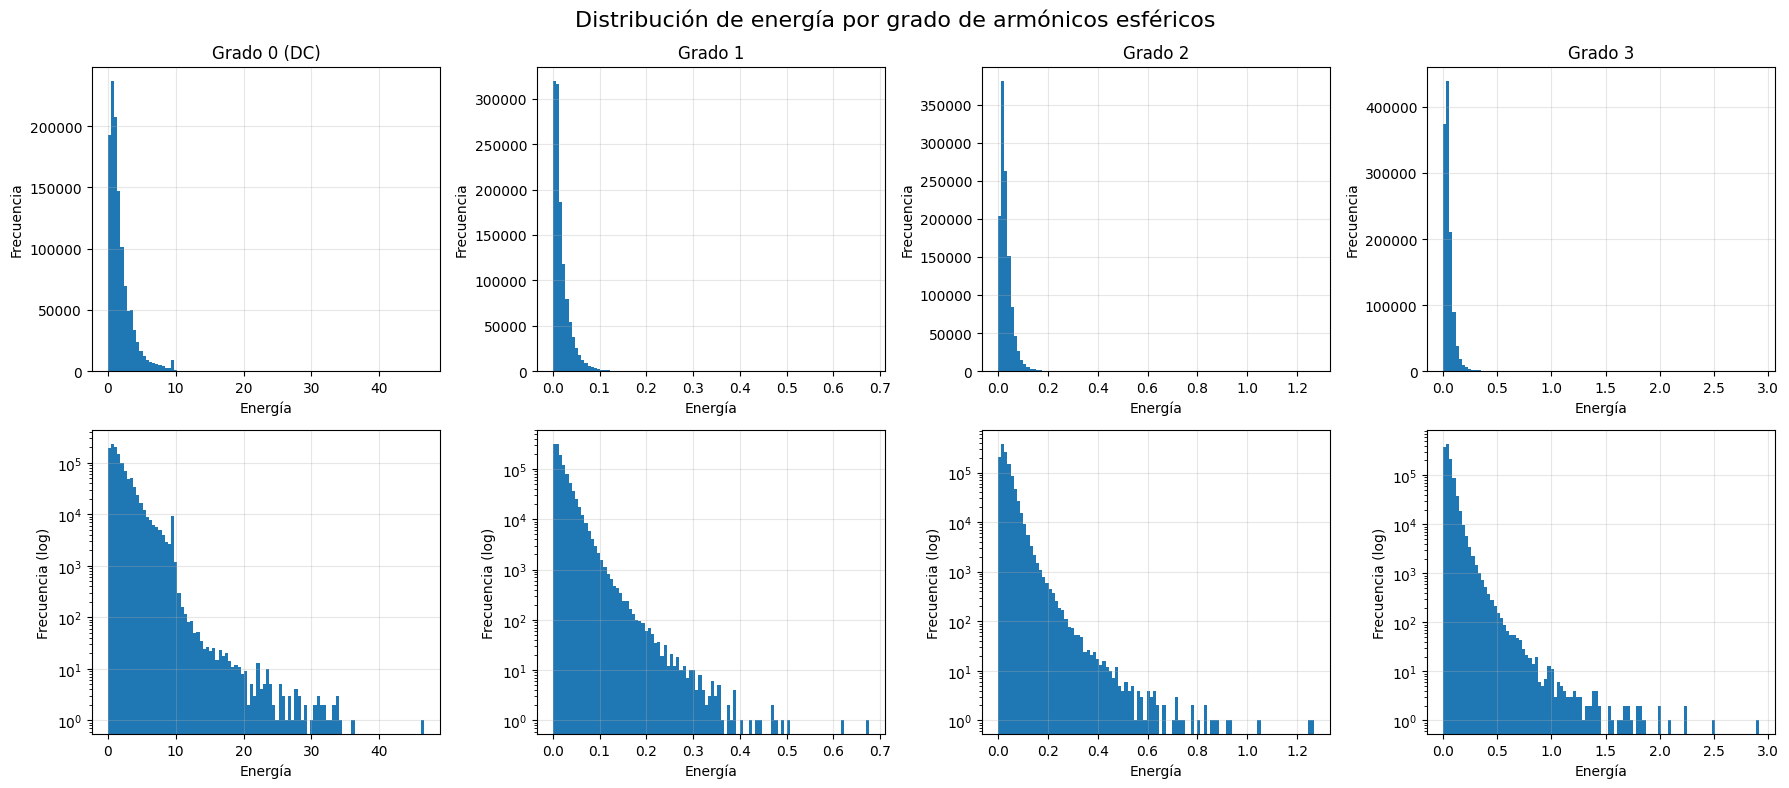

In [ ]:
import matplotlib.pyplot as plt

energies = [E0, E1, E2, E3]
titles = ["Grado 0 (DC)", "Grado 1", "Grado 2", "Grado 3"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, (E, title) in enumerate(zip(energies, titles)):

    # Histograma normal
    axes[0, i].hist(E, bins=100)
    axes[0, i].set_title(title)
    axes[0, i].set_xlabel("Energía")
    axes[0, i].set_ylabel("Frecuencia")
    axes[0, i].grid(alpha=0.3)

    # Histograma log
    axes[1, i].hist(E, bins=100)
    axes[1, i].set_yscale("log")
    axes[1, i].set_xlabel("Energía")
    axes[1, i].set_ylabel("Frecuencia (log)")
    axes[1, i].grid(alpha=0.3)

plt.suptitle(
    "Distribución de energía por grado de armónicos esféricos",
    fontsize=16
)

plt.tight_layout()
plt.show()

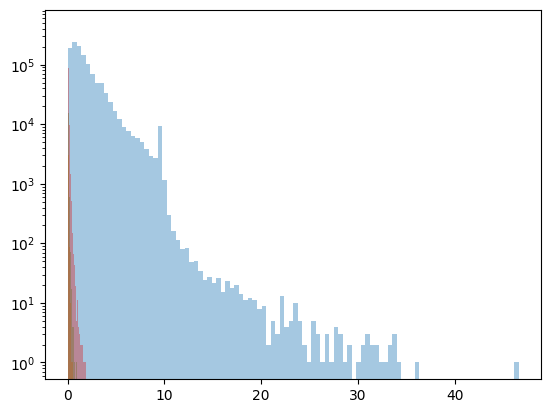

In [27]:
plt.hist(E0, bins=100, alpha=0.4, label="E0")
plt.hist(E1, bins=100, alpha=0.4, label="E1")
plt.hist(E2, bins=100, alpha=0.4, label="E2")
plt.hist(E3, bins=100, alpha=0.4, label="E3")

plt.yscale("log")

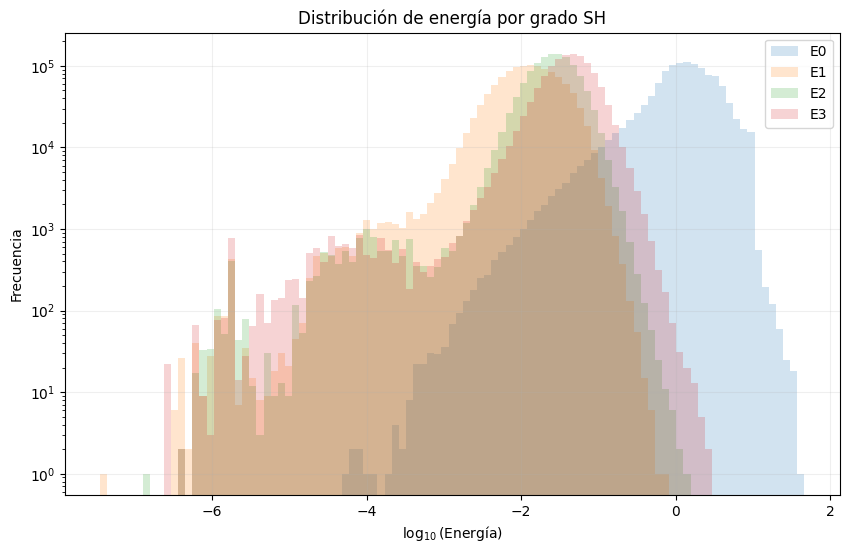

In [33]:
eps = 1e-12

logE0 = np.log10(E0 + eps)
logE1 = np.log10(E1 + eps)
logE2 = np.log10(E2 + eps)
logE3 = np.log10(E3 + eps)

all_logE = np.concatenate([logE0, logE1, logE2, logE3])
bins = np.linspace(all_logE.min(), all_logE.max(), 100)

plt.figure(figsize=(10, 6))

plt.hist(logE0, bins=bins, alpha=0.2, label="E0")
plt.hist(logE1, bins=bins, alpha=0.2, label="E1")
plt.hist(logE2, bins=bins, alpha=0.2, label="E2")
plt.hist(logE3, bins=bins, alpha=0.2, label="E3")

plt.xlabel(r"$\log_{10}(\mathrm{Energía})$")
plt.ylabel("Frecuencia")
plt.yscale("log")
plt.title("Distribución de energía por grado SH")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Valores númericos

In [21]:
for name, E in [
    ("E0", E0),
    ("E1", E1),
    ("E2", E2),
    ("E3", E3),
]:
    print(f"\n{name}")
    print(f"  mean   : {E.mean():.6f}")
    print(f"  std    : {E.std():.6f}")
    print(f"  median : {np.median(E):.6f}")
    print(f"  max    : {E.max():.6f}")


E0
  mean   : 1.848481
  std    : 1.792142
  median : 1.299110
  max    : 46.601242

E1
  mean   : 0.018528
  std    : 0.018847
  median : 0.012515
  max    : 0.676816

E2
  mean   : 0.032473
  std    : 0.026274
  median : 0.025919
  max    : 1.269251

E3
  mean   : 0.053381
  std    : 0.047675
  median : 0.042055
  max    : 2.920210


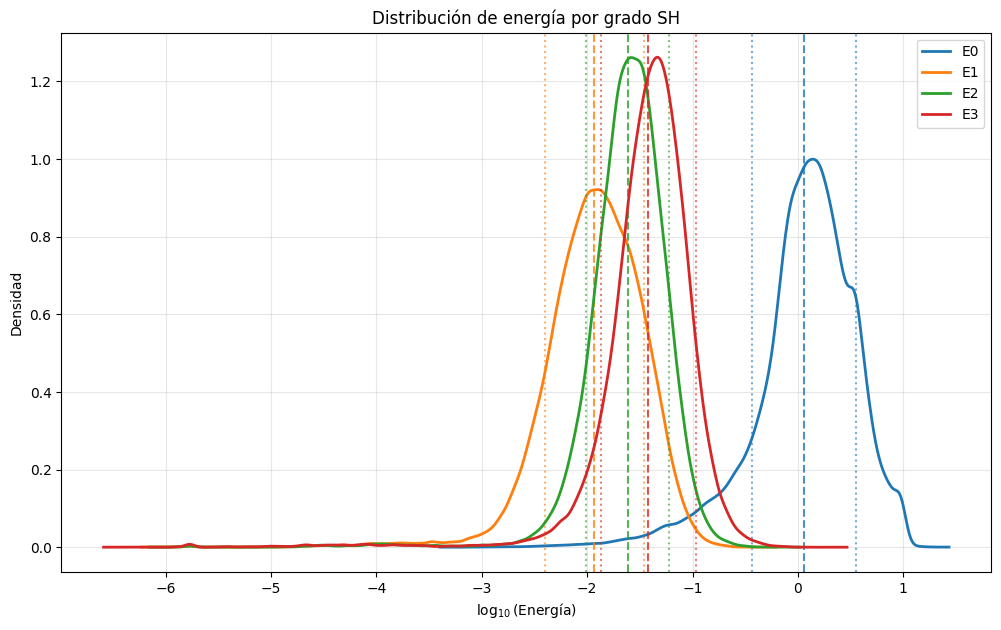

In [ ]:
from scipy.stats import gaussian_kde

eps = 1e-12

datasets = {
    "E0": E0,
    "E1": E1,
    "E2": E2,
    "E3": E3
}

plt.figure(figsize=(12, 7))

for name, E in datasets.items():

    logE = np.log10(E + eps)
    sample_size = min(100000, len(logE))
    sample = np.random.choice(logE, sample_size, replace=False)
    kde = gaussian_kde(sample)

    x = np.linspace(sample.min(), sample.max(), 1000)

    y = kde(x)

    line, = plt.plot(x, y, linewidth=2, label=name)
    color = line.get_color()
    mean = logE.mean()
    std = logE.std()

    # Media
    plt.axvline(mean, color=color, linestyle="--", alpha=0.8)

    # desviación estándar
    plt.axvline(mean - std, color=color, linestyle=":", alpha=0.6)
    plt.axvline(mean + std, color=color, linestyle=":", alpha=0.6)

plt.xlabel(r"$\log_{10}(\mathrm{Energía})$")
plt.ylabel("Densidad")
plt.title("Distribución de energía por grado SH")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Ratio: se pueden dar 3 casos

- Ratio ~~ 0: La apariencia del gaussiano es prácticamente independiente de la dirección de observación.

- Ratio ~~ 1: La dirección de observación importa bastante, se puede interpretar como material difuso.

- Ratio >> 1: El color depende fuertemente de la dirección de observación (Se vuelve altamente asintrópico). 

In [38]:
ratio = (E1 + E2 + E3) / (E0 + eps)

Se puede definir fraction que es básicamente lo mismo que ratio pero acotado a [0,1] de donde se puede expresar el porcentaje de energía direccional para la gaussiana. Ej: fraction = 0.2 -> cerca del 20% de la energía es direccional/asintrópica

In [41]:
fraction = (E1 + E2 + E3) / (E0 + E1 + E2 + E3 + 1e-12)

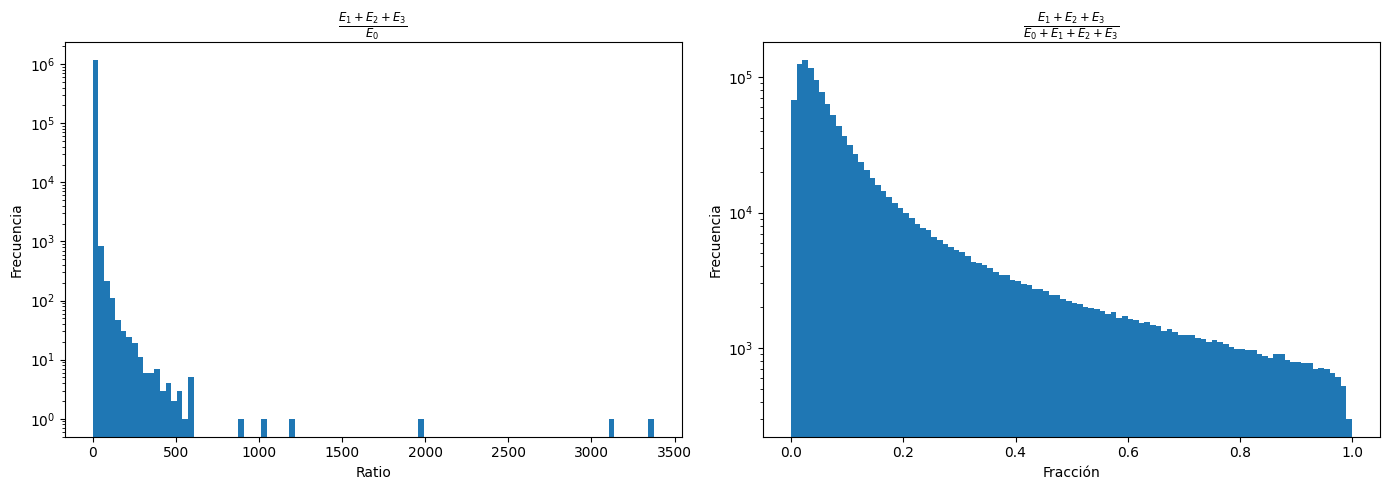

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(ratio, bins=100)
axes[0].set_title(r"$\frac{E_1+E_2+E_3}{E_0}$")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Frecuencia")
axes[0].set_yscale("log")

axes[1].hist(fraction, bins=100)
axes[1].set_title(
    r"$\frac{E_1+E_2+E_3}{E_0+E_1+E_2+E_3}$"
)
axes[1].set_xlabel("Fracción")
axes[1].set_ylabel("Frecuencia")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

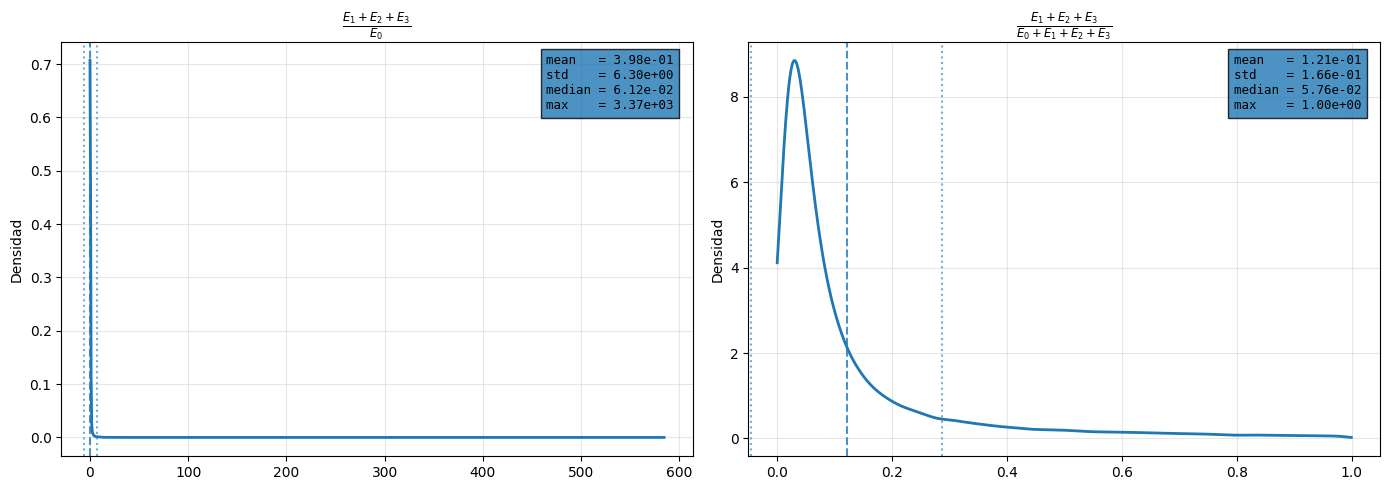

In [44]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14,5))

for ax, values, title in [
    (axes[0], ratio,
     r"$\frac{E_1+E_2+E_3}{E_0}$"),
    (axes[1], fraction,
     r"$\frac{E_1+E_2+E_3}{E_0+E_1+E_2+E_3}$")
]:

    sample_size = min(100000, len(values))

    sample = np.random.choice(
        values,
        sample_size,
        replace=False
    )

    kde = gaussian_kde(sample)

    x = np.linspace(
        sample.min(),
        sample.max(),
        1000
    )

    y = kde(x)

    ax.plot(x, y, linewidth=2)

    mean = values.mean()
    std = values.std()
    stats = (
        f"mean   = {values.mean():.2e}\n"
        f"std    = {values.std():.2e}\n"
        f"median = {np.median(values):.2e}\n"
        f"max    = {values.max():.2e}"
    )
    
    ax.text(
        0.97,      # x relativa
        0.97,      # y relativa
        stats,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        family="monospace",
        bbox=dict(alpha=0.8)
    )

    ax.axvline(
        mean,
        linestyle="--",
        alpha=0.8,
        label="mean"
    )

    ax.axvline(
        mean - std,
        linestyle=":",
        alpha=0.6
    )

    ax.axvline(
        mean + std,
        linestyle=":",
        alpha=0.6
    )

    ax.set_title(title)
    ax.set_ylabel("Densidad")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Generación de las 15 variantes energéticas 

In [ ]:
from itertools import product
from copy import deepcopy
from pathlib import Path
from plyfile import PlyData

OUTPUT_DIR = Path("variants")
OUTPUT_DIR.mkdir(exist_ok=True)

SH_GROUPS = {
    "E0": ["f_dc_0", "f_dc_1", "f_dc_2"],
    "E1": [f"f_rest_{i}" for i in range(0, 9)],
    "E2": [f"f_rest_{i}" for i in range(9, 24)],
    "E3": [f"f_rest_{i}" for i in range(24, 45)],
}

configs = [
    cfg
    for cfg in product([False, True], repeat=4)
    if cfg != (True, True, True, True)
]

for E0_on, E1_on, E2_on, E3_on in configs:

    ply_copy = deepcopy(plydata)
    vert_copy = ply_copy["vertex"].data

    config = {
        "E0": E0_on,
        "E1": E1_on,
        "E2": E2_on,
        "E3": E3_on,
    }

    for level, enabled in config.items():
        if not enabled:
            for field in SH_GROUPS[level]:
                vert_copy[field] = 0.0

    filename = (
        f"E0_{int(E0_on)}_"
        f"E1_{int(E1_on)}_"
        f"E2_{int(E2_on)}_"
        f"E3_{int(E3_on)}.ply"
    )

    output_path = OUTPUT_DIR / filename

    ply_copy.write(str(output_path))

    print(f"Exportado: {output_path}")

print(f"\nGeneradas {len(configs)} variantes.")

Exportado: variants/E0_0_E1_0_E2_0_E3_0.ply
Exportado: variants/E0_0_E1_0_E2_0_E3_1.ply
Exportado: variants/E0_0_E1_0_E2_1_E3_0.ply
Exportado: variants/E0_0_E1_0_E2_1_E3_1.ply
Exportado: variants/E0_0_E1_1_E2_0_E3_0.ply
Exportado: variants/E0_0_E1_1_E2_0_E3_1.ply
Exportado: variants/E0_0_E1_1_E2_1_E3_0.ply
Exportado: variants/E0_0_E1_1_E2_1_E3_1.ply
Exportado: variants/E0_1_E1_0_E2_0_E3_0.ply
Exportado: variants/E0_1_E1_0_E2_0_E3_1.ply
Exportado: variants/E0_1_E1_0_E2_1_E3_0.ply
Exportado: variants/E0_1_E1_0_E2_1_E3_1.ply
Exportado: variants/E0_1_E1_1_E2_0_E3_0.ply
Exportado: variants/E0_1_E1_1_E2_0_E3_1.ply
Exportado: variants/E0_1_E1_1_E2_1_E3_0.ply

Generadas 15 variantes.


### Aquí se ejecuta el archivo de capture_all.html 

se utiliza el enlace `http://localhost:8000/capture_all.html`

Tras utilizar los htmls se procede a comparar las capturas

In [53]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IMG_DIR = Path("capturas")

BASE_IMAGES = [
    Path("screenshots/base/base_1.png"),
    Path("screenshots/base/base_2.png"),
    Path("screenshots/base/base_3.png"),
]

VIEWS = ["v1", "v2", "v3"]

In [ ]:
def plot_group(title, configs):

    nrows = len(configs) + 1

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=3,
        figsize=(15, 4 * nrows)
    )

    if nrows == 1:
        axes = axes.reshape(1, 3)

    for col in range(3):
        axes[0, col].set_title(f"Vista {col+1}", fontsize=14)

    for col in range(3):

        img = mpimg.imread(BASE_IMAGES[col])
        axes[0, col].imshow(img)
        axes[0, col].axis("off")

        axes[0, col].set_title(
            BASE_IMAGES[col].name,
            fontsize=10
        )

    for row, (label, filename_base) in enumerate(configs, start=1):

        for col, view in enumerate(VIEWS):

            img_path = IMG_DIR / f"{filename_base}_{view}.png"
            img = mpimg.imread(img_path)

            axes[row, col].imshow(img)
            axes[row, col].axis("off")

            axes[row, col].set_title(
                f"{filename_base}_{view}",
                fontsize=9
            )

    fig.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

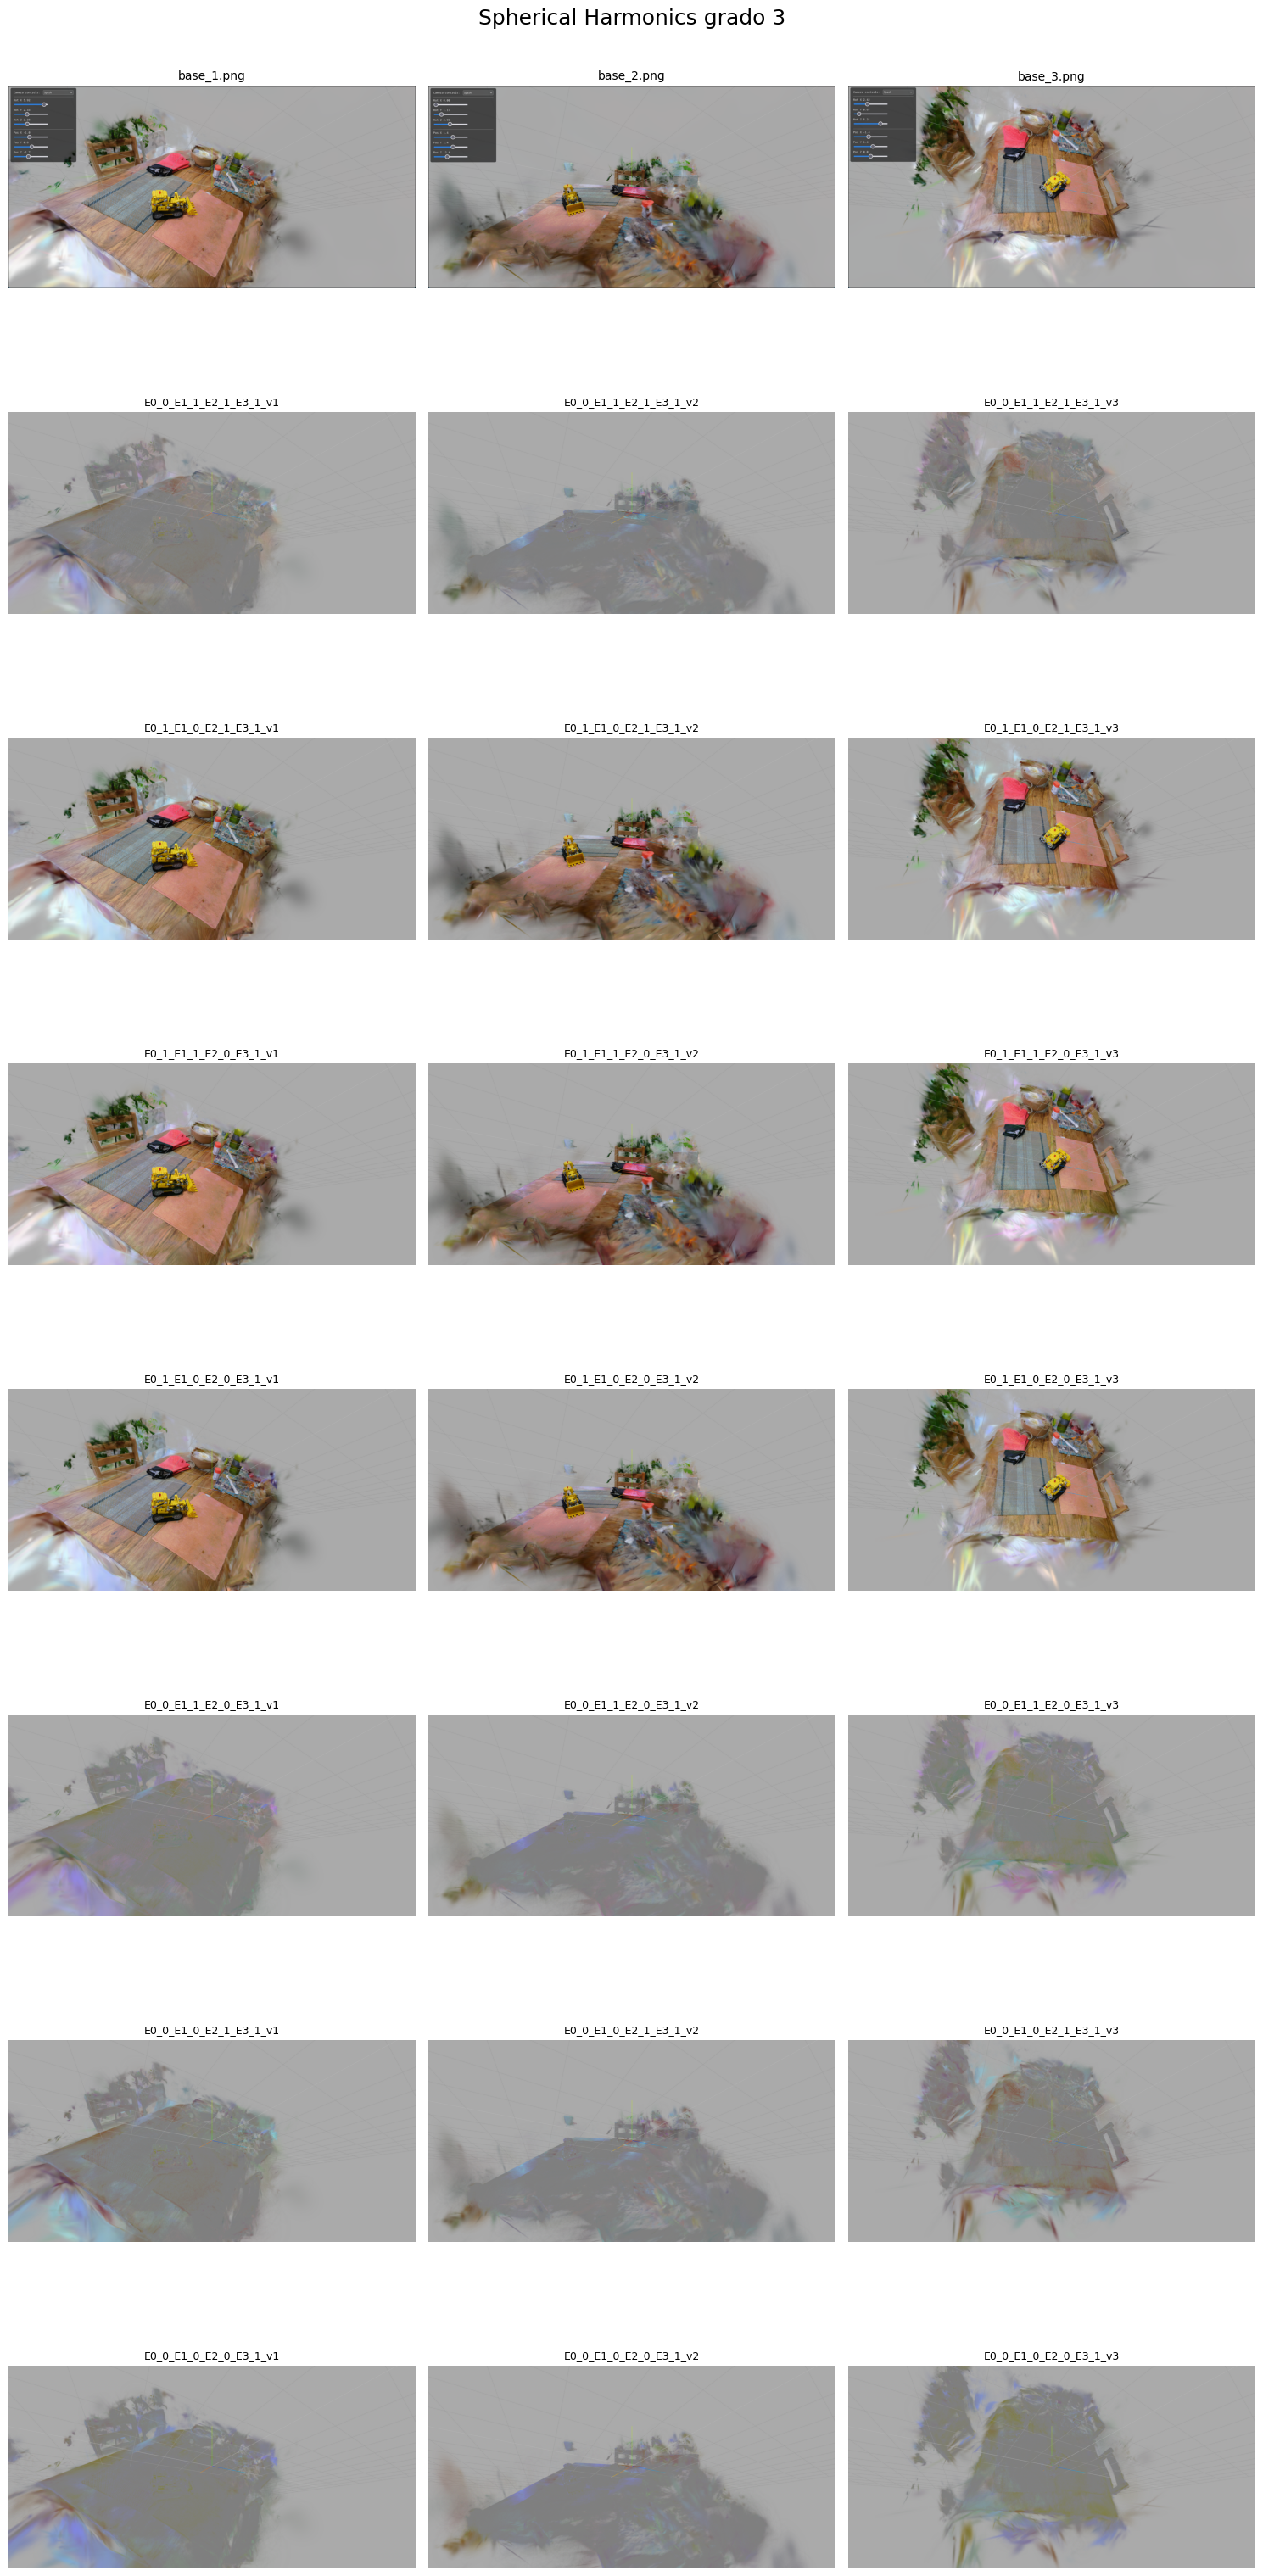

In [67]:
grado3 = [

    ("E1+E2+E3",
     "E0_0_E1_1_E2_1_E3_1"),

    ("E0+E2+E3",
     "E0_1_E1_0_E2_1_E3_1"),

    ("E0+E1+E3",
     "E0_1_E1_1_E2_0_E3_1"),

    ("E0+E3",
     "E0_1_E1_0_E2_0_E3_1"),

    ("E1+E3",
     "E0_0_E1_1_E2_0_E3_1"),

    ("E2+E3",
     "E0_0_E1_0_E2_1_E3_1"),

    ("E3",
     "E0_0_E1_0_E2_0_E3_1"),
]

plot_group(
    "Spherical Harmonics grado 3",
    grado3
)

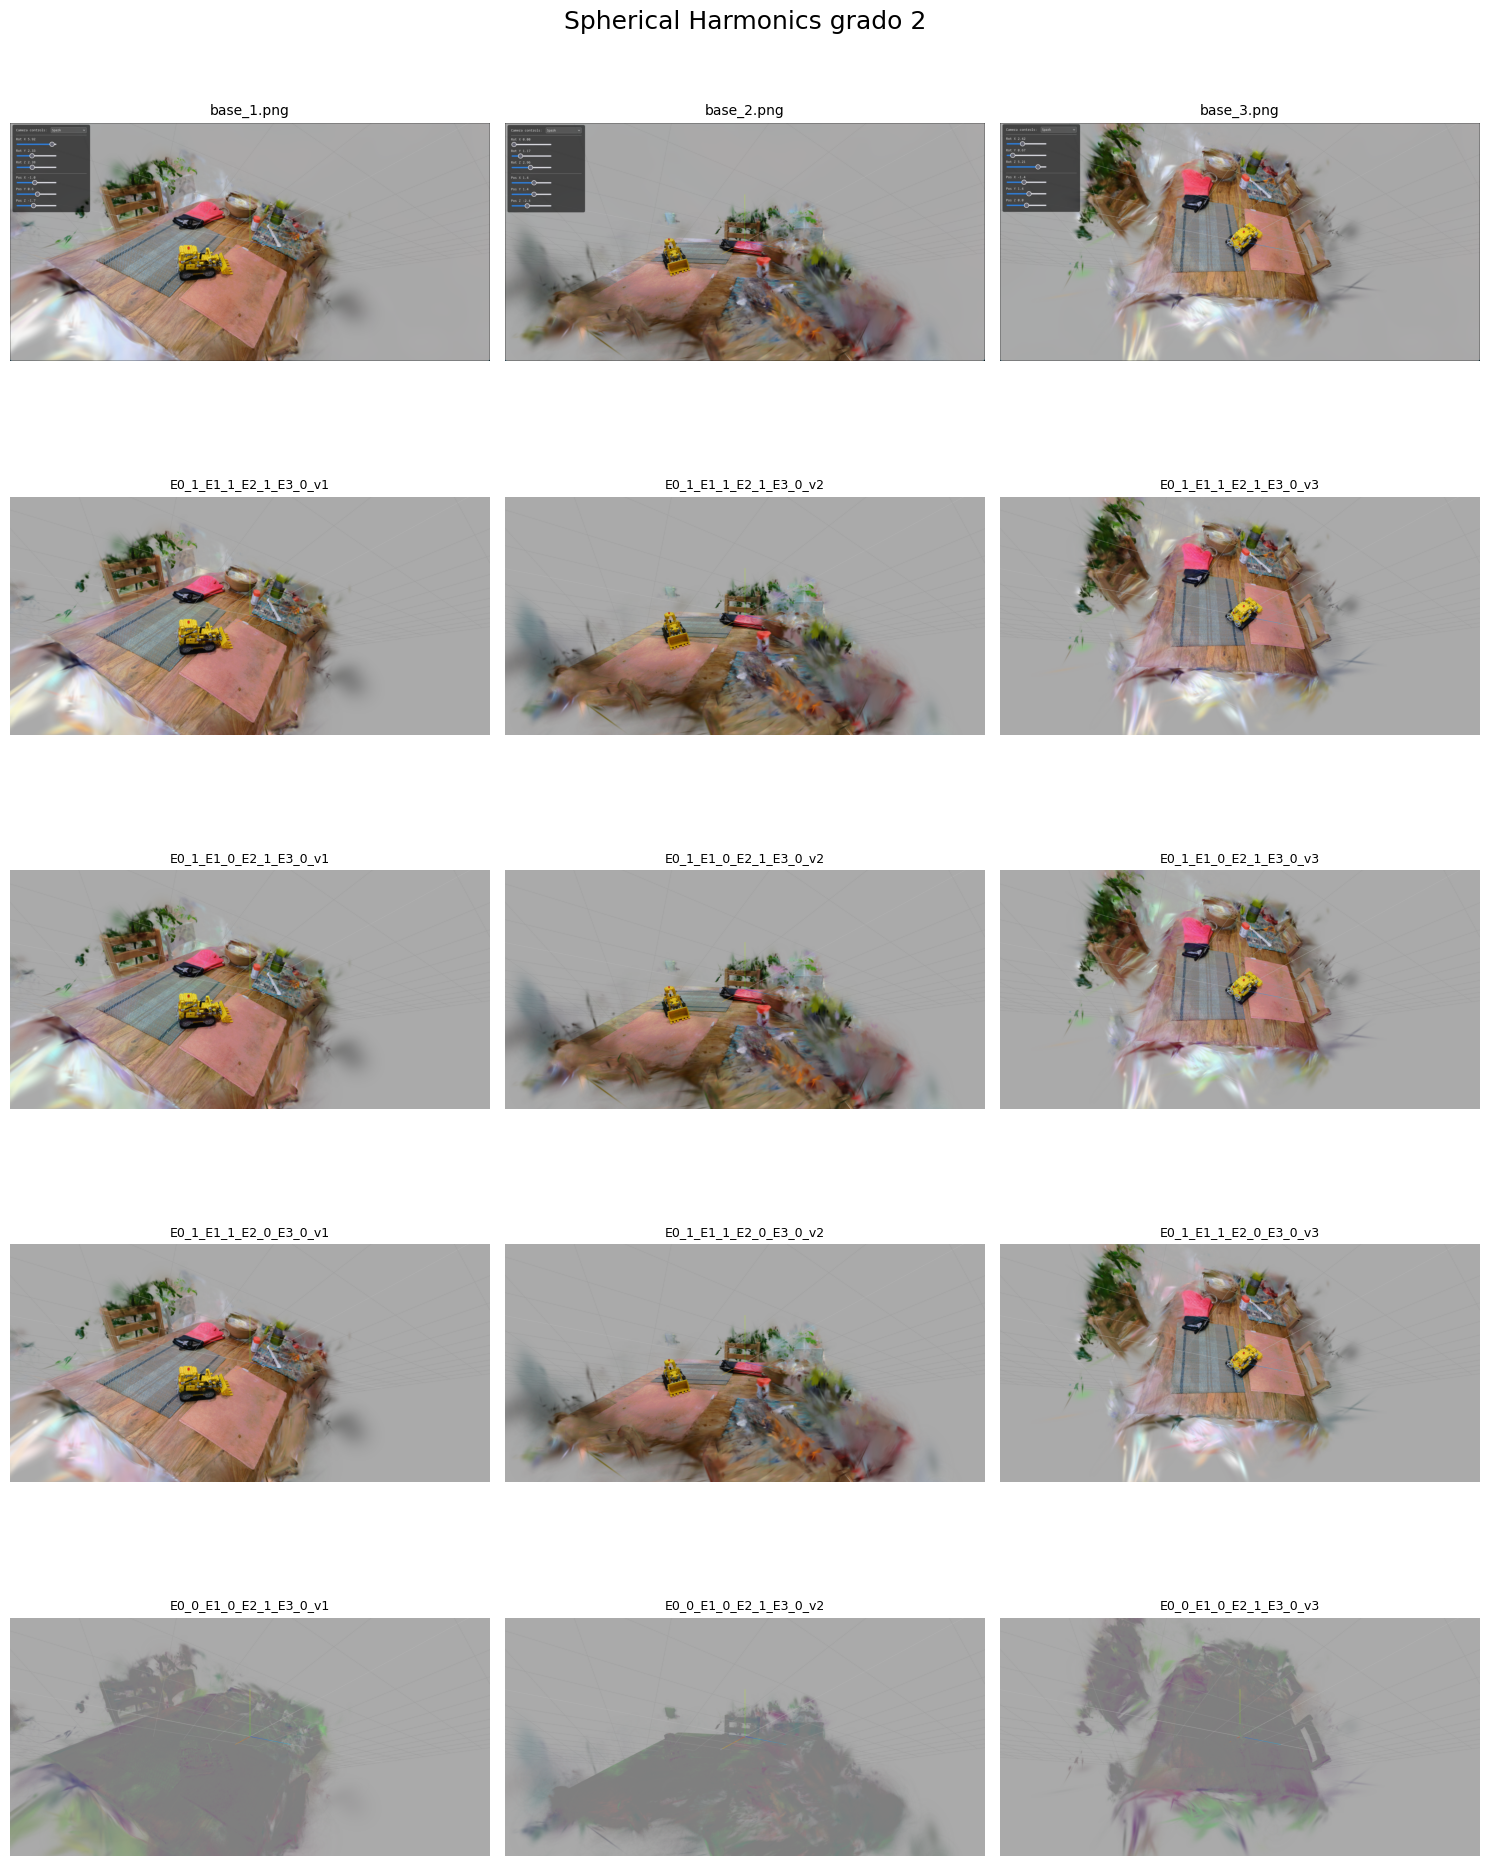

In [68]:
grado2 = [
    ("E0+E1+E2", "E0_1_E1_1_E2_1_E3_0"),
    ("E0+E2",    "E0_1_E1_0_E2_1_E3_0"),
    ("E0+E1",    "E0_1_E1_1_E2_0_E3_0"),
    ("E2",       "E0_0_E1_0_E2_1_E3_0"),
]

plot_group("Spherical Harmonics grado 2", grado2)

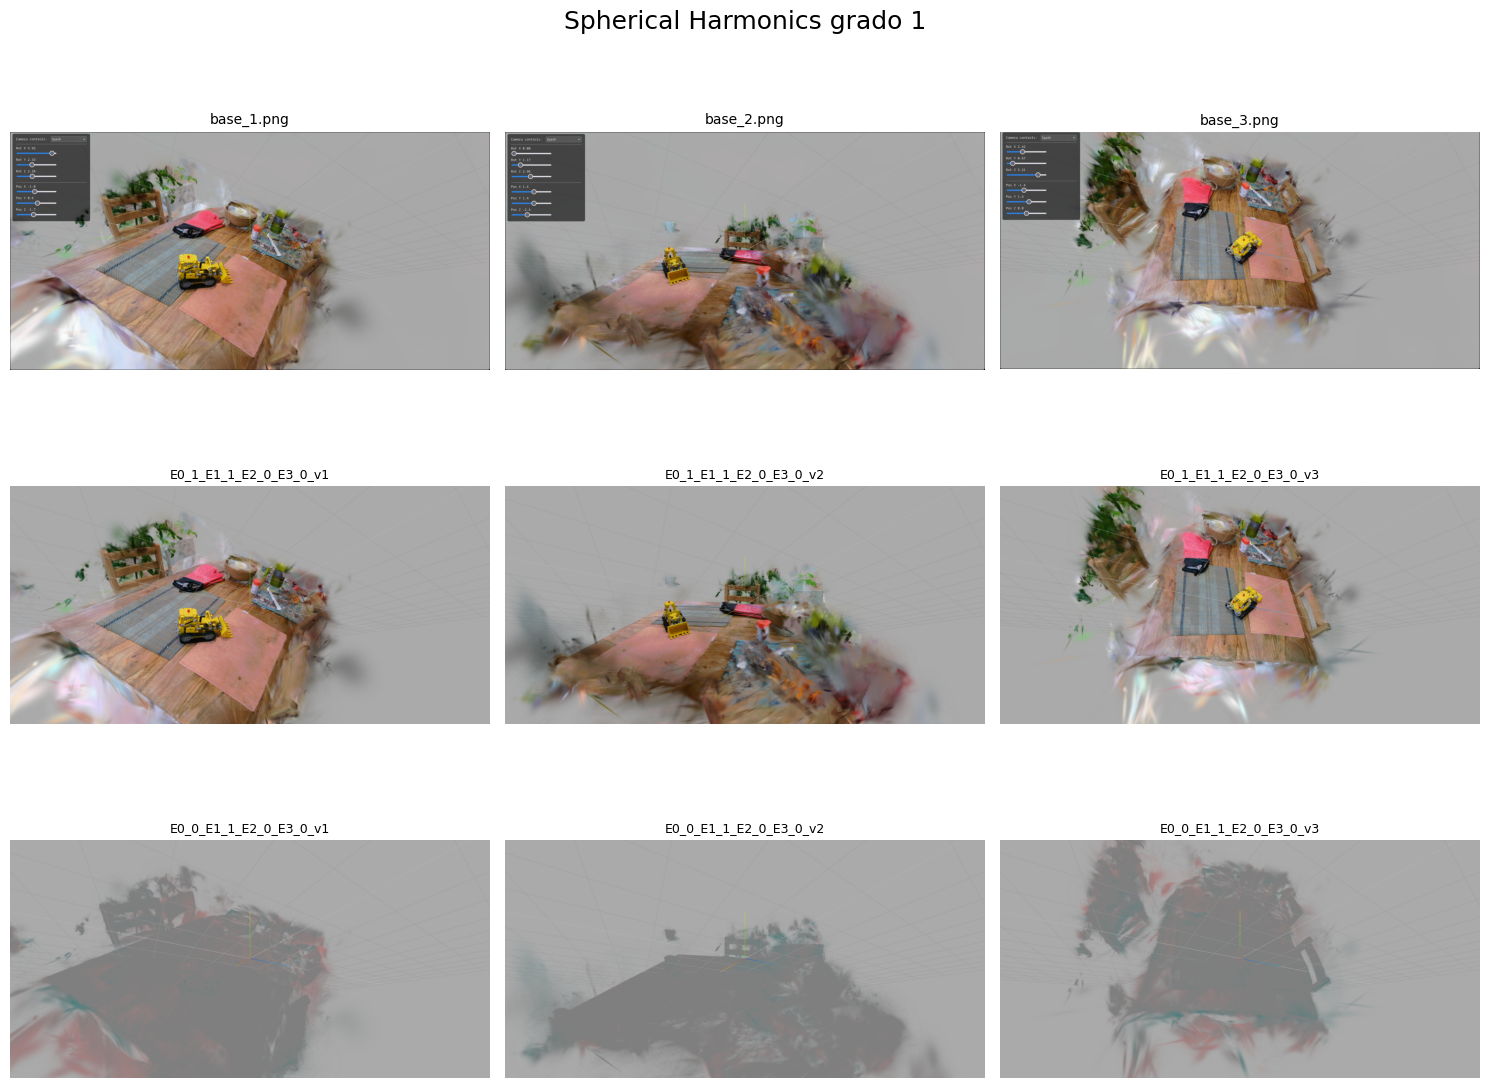

In [69]:
grado1 = [
    ("E0+E1", "E0_1_E1_1_E2_0_E3_0"),
    ("E1",    "E0_0_E1_1_E2_0_E3_0"),
]

plot_group("Spherical Harmonics grado 1", grado1)

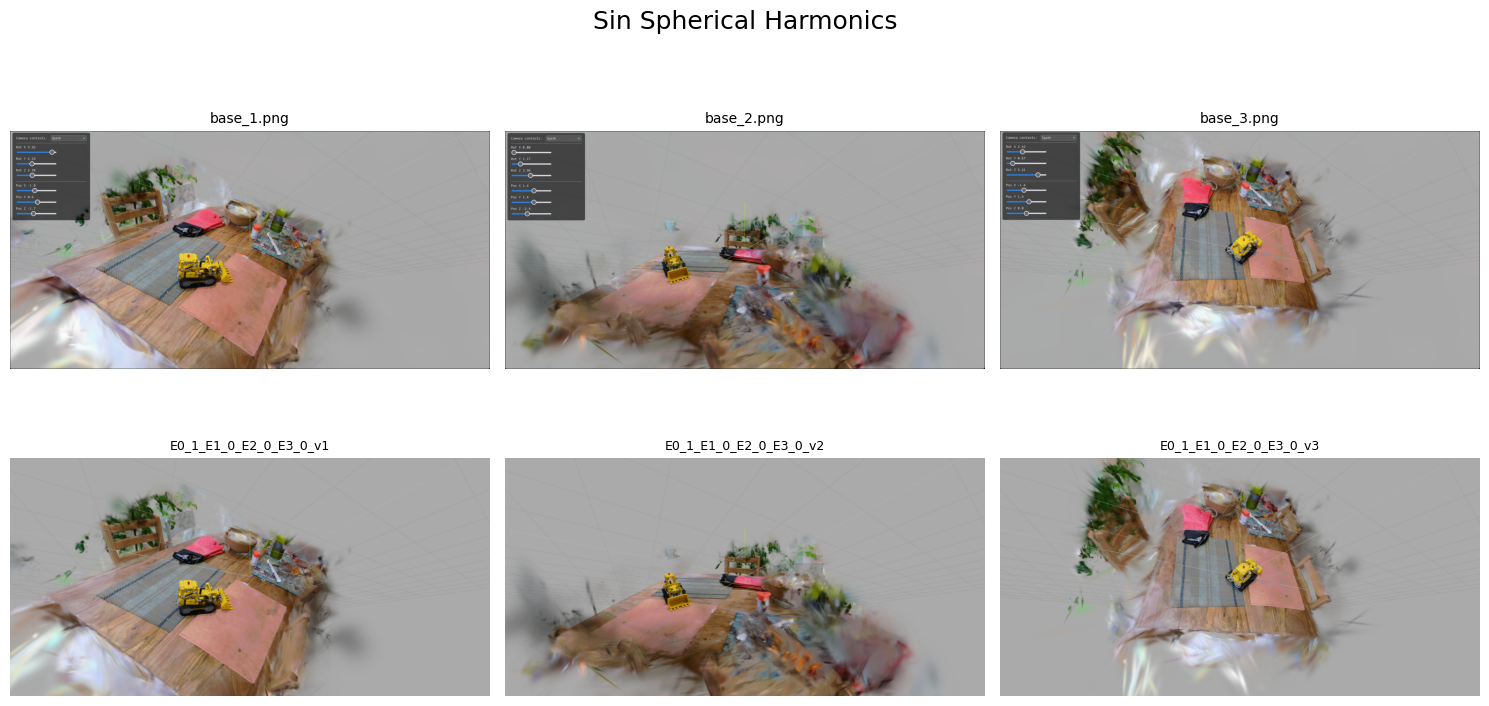

In [70]:
sin_sh = [
    ("E0", "E0_1_E1_0_E2_0_E3_0"),
]

plot_group("Sin Spherical Harmonics", sin_sh)

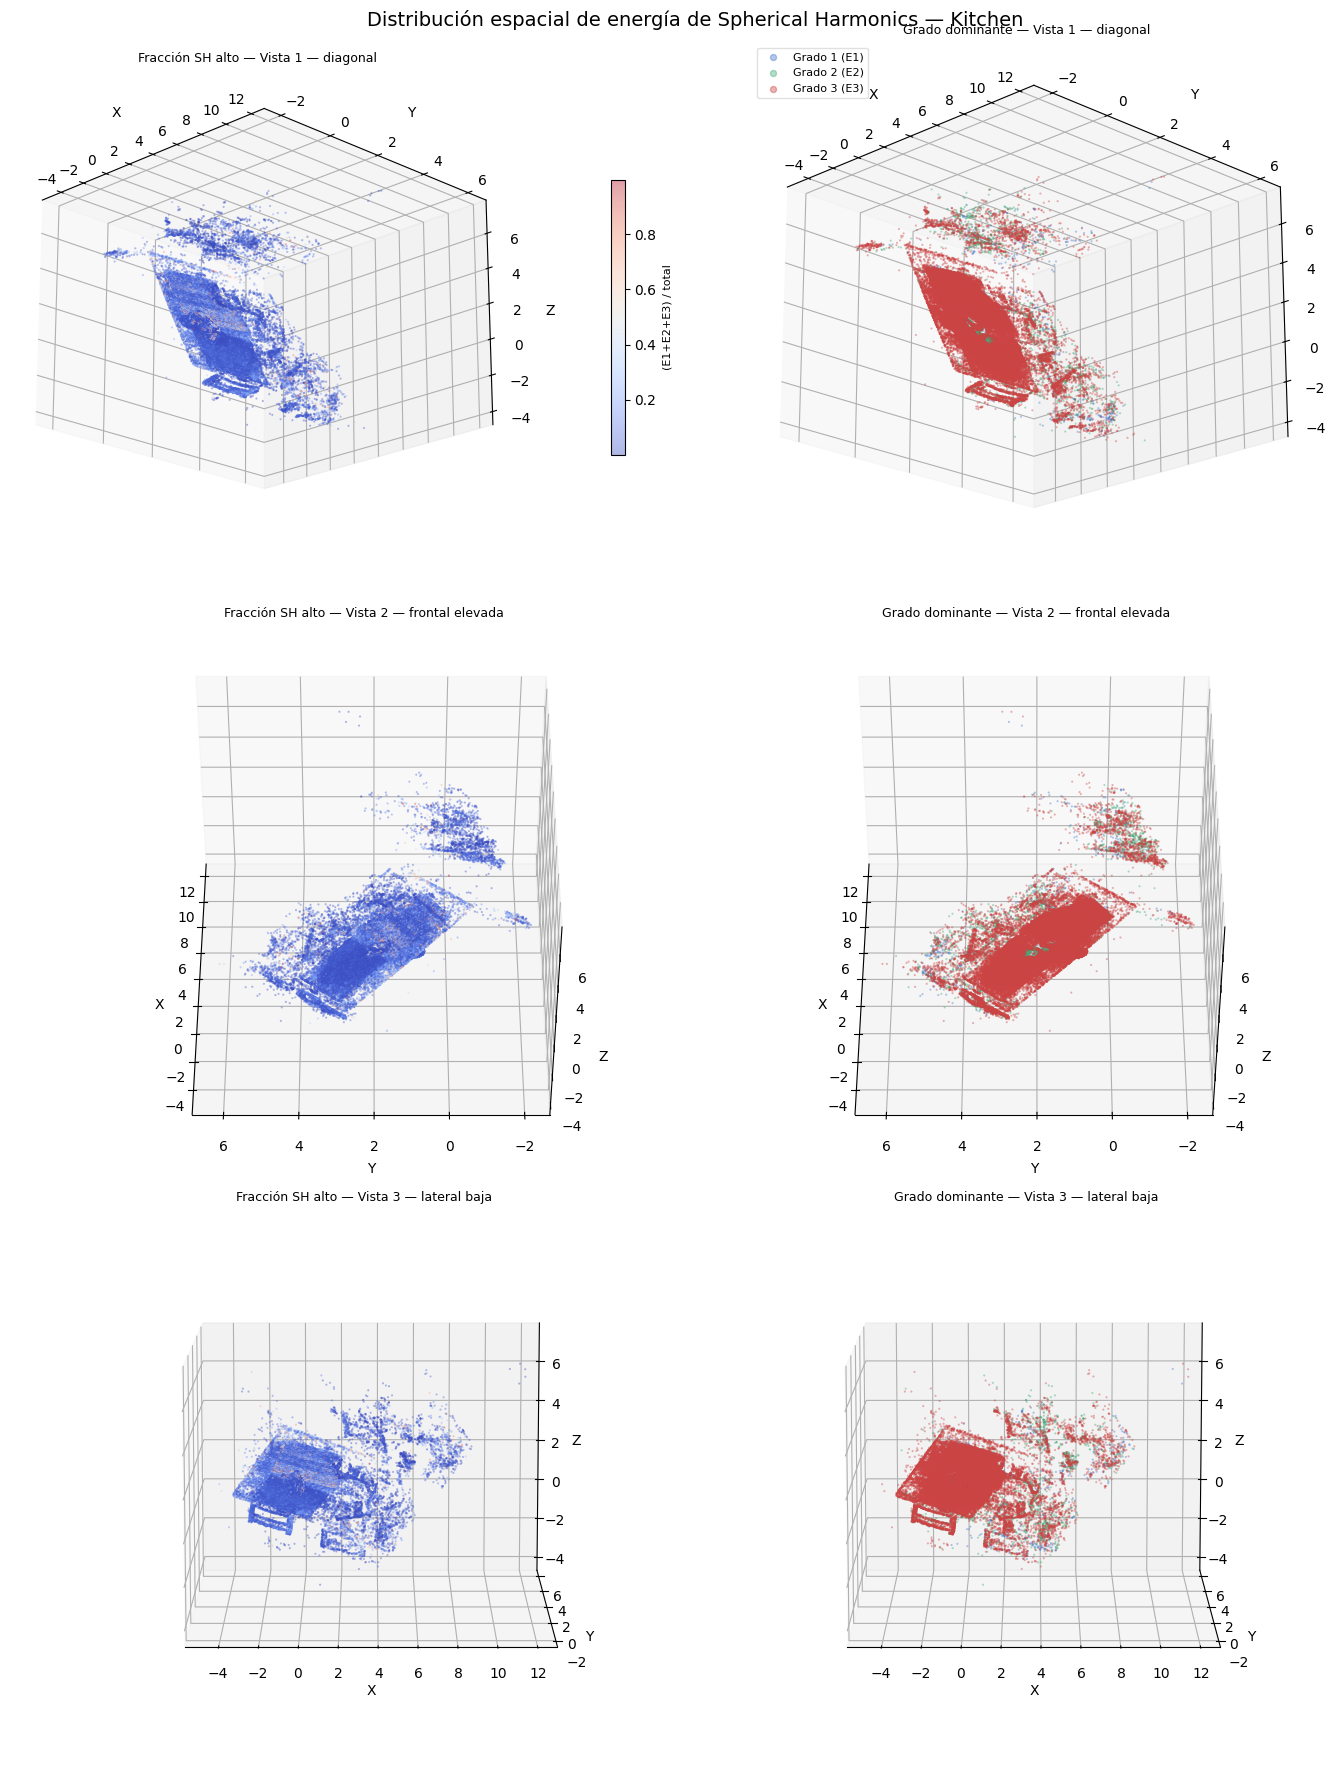

Guardado: vis/scatter3d_sh.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from plyfile import PlyData
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from pathlib import Path

PATH = "Poison-3DGS/kitchen_3dgs.ply"

plydata = PlyData.read(PATH)
vert = plydata["vertex"].data

x = vert["x"].astype(np.float32)
y = vert["y"].astype(np.float32)
z = vert["z"].astype(np.float32)


def energy(*fields):
    return np.sum(np.stack(fields, axis=0) ** 2, axis=0)

E0 = energy(vert["f_dc_0"], vert["f_dc_1"], vert["f_dc_2"])
E1 = energy(*[vert[f"f_rest_{i}"] for i in range(0,  9)])
E2 = energy(*[vert[f"f_rest_{i}"] for i in range(9,  24)])
E3 = energy(*[vert[f"f_rest_{i}"] for i in range(24, 45)])

eps = 1e-12
fraction  = (E1 + E2 + E3) / (E0 + E1 + E2 + E3 + eps)
dominant  = np.argmax(np.stack([E1, E2, E3], axis=0), axis=0)

# SUBSAMPLE
N   = 80_000
rng = np.random.default_rng(42)
idx = rng.choice(len(x), size=N, replace=False)

xs, ys, zs = x[idx], y[idx], z[idx]
frac_s     = fraction[idx]
dominant_s = dominant[idx]

VIEWS = [
    {"elev": -20, "azim": -45,  "label": "Vista 1 — diagonal"},
    {"elev":  45, "azim":  180, "label": "Vista 2 — frontal elevada"},
    {"elev":  10, "azim":  270, "label": "Vista 3 — lateral baja"},
]

DEGREE_COLORS = {0: "#4477CC", 1: "#44AA77", 2: "#CC4444"}
DEGREE_LABELS = {0: "Grado 1 (E1)", 1: "Grado 2 (E2)", 2: "Grado 3 (E3)"}


fig = plt.figure(figsize=(14, 18))
fig.suptitle(
    "Distribución espacial de energía de Spherical Harmonics — Kitchen",
    fontsize=14
)

for row, view in enumerate(VIEWS):


    ax_left = fig.add_subplot(3, 2, row * 2 + 1, projection="3d")

    sc = ax_left.scatter(
        xs, ys, zs,
        c=frac_s,
        cmap="coolwarm",
        s=0.3,
        alpha=0.4,
        rasterized=True
    )
    ax_left.view_init(elev=view["elev"], azim=view["azim"])
    ax_left.set_title(f"Fracción SH alto — {view['label']}", fontsize=9)
    ax_left.set_xlabel("X"); ax_left.set_ylabel("Y"); ax_left.set_zlabel("Z")

    if row == 0:
        cb = fig.colorbar(sc, ax=ax_left, pad=0.15, shrink=0.5)
        cb.set_label("(E1+E2+E3) / total", fontsize=8)


    ax_right = fig.add_subplot(3, 2, row * 2 + 2, projection="3d")

    for deg in range(3):
        mask = dominant_s == deg
        ax_right.scatter(
            xs[mask], ys[mask], zs[mask],
            c=DEGREE_COLORS[deg],
            label=DEGREE_LABELS[deg],
            s=0.3,
            alpha=0.4,
            rasterized=True
        )
    ax_right.view_init(elev=view["elev"], azim=view["azim"])
    ax_right.set_title(f"Grado dominante — {view['label']}", fontsize=9)
    ax_right.set_xlabel("X"); ax_right.set_ylabel("Y"); ax_right.set_zlabel("Z")

    if row == 0:
        ax_right.legend(markerscale=8, loc="upper left", fontsize=8, framealpha=0.6)


Path("vis").mkdir(exist_ok=True)

plt.tight_layout()
plt.savefig("vis/scatter3d_sh.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: vis/scatter3d_sh.png")

Debido a que la energía de E3 cuenta con una cantidad de componentes mucho mayor a E1 y E2 la suma de energías por componentes tiende a ser mayor. Por lo que se hará el mismo experimento normalizando las energías.

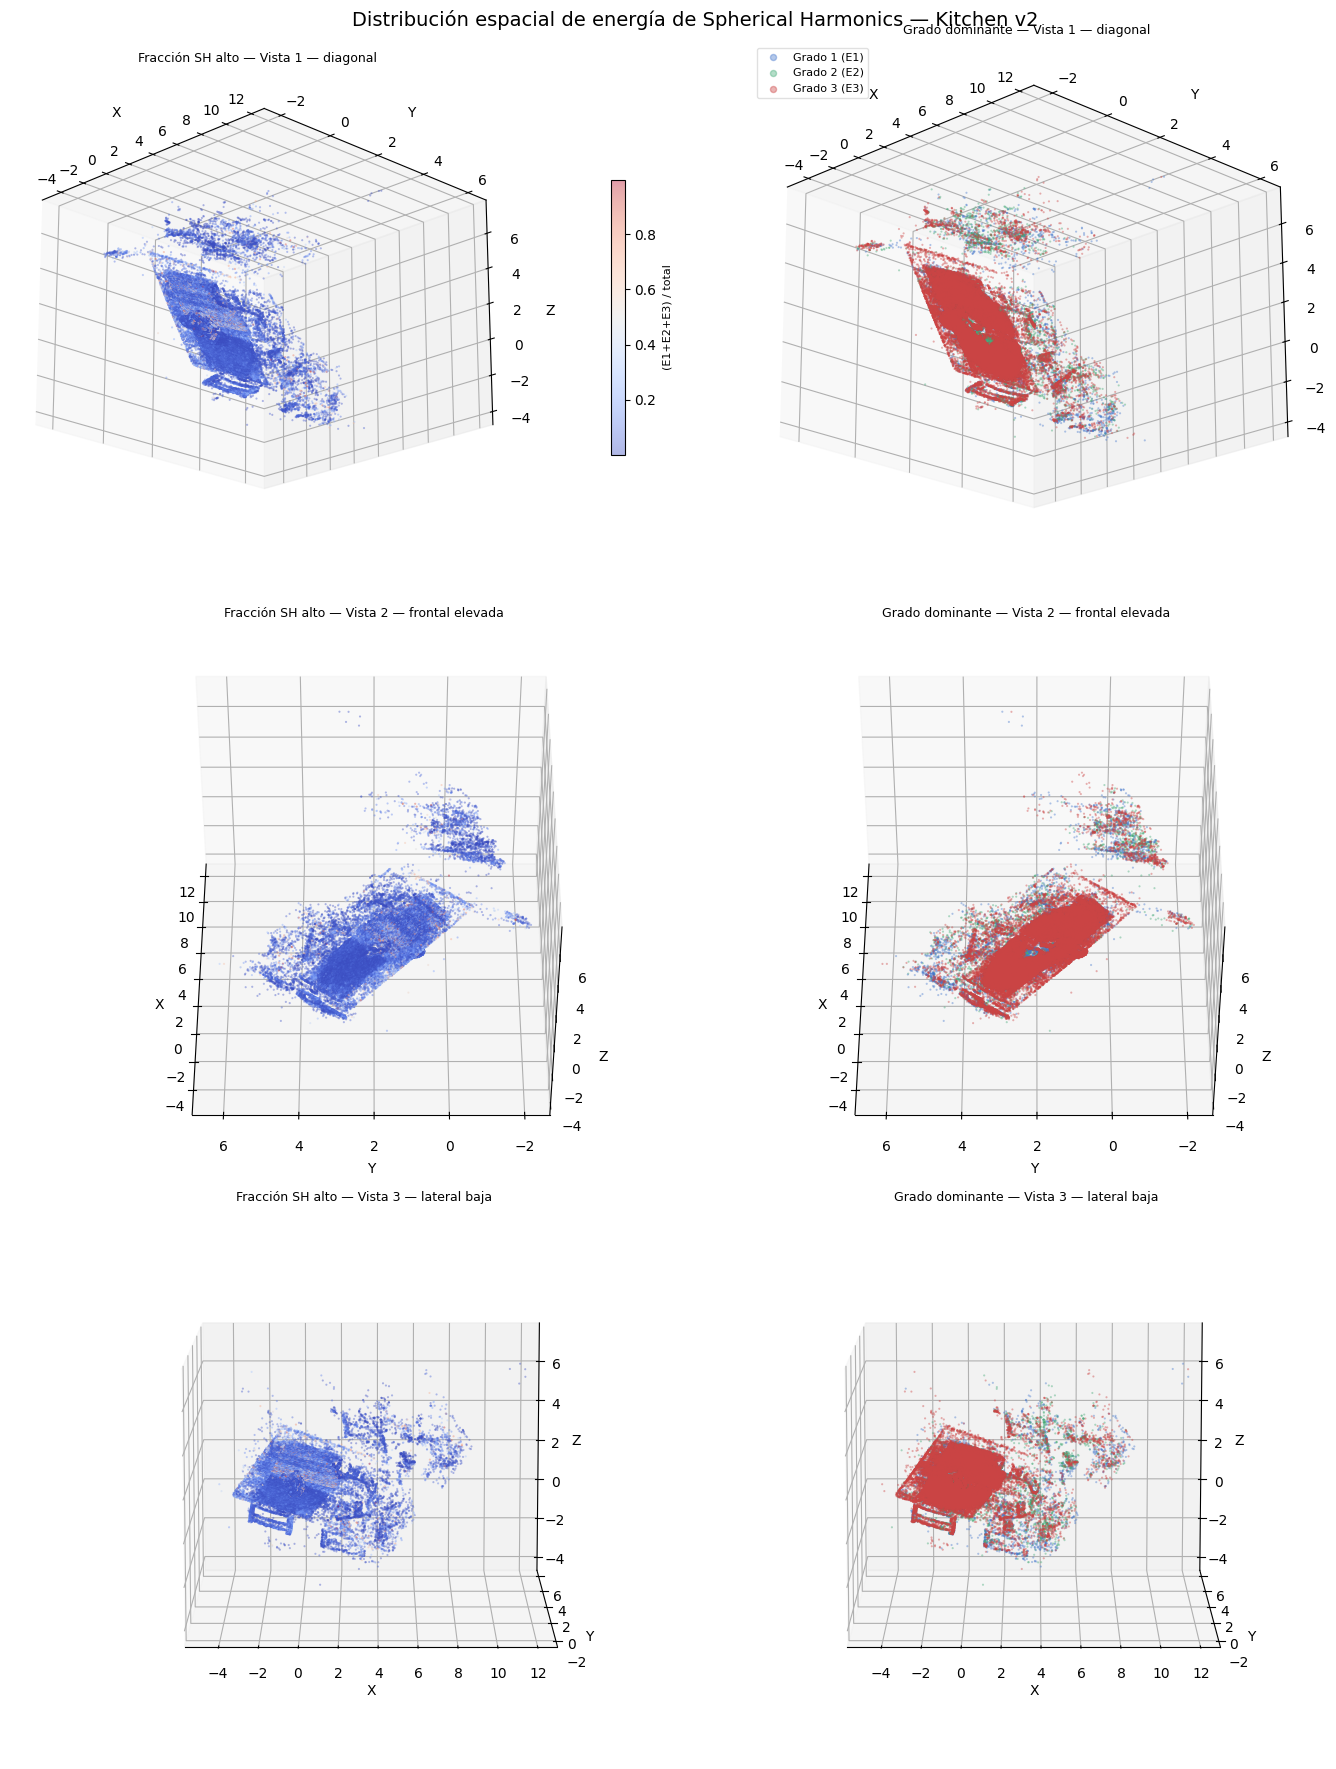

Guardado: vis/scatter3d_sh.png


In [77]:


PATH = "Poison-3DGS/kitchen_3dgs.ply"

E1_norm = E1 / 9
E2_norm = E2 / 15
E3_norm = E3 / 21

dominant = np.argmax(np.stack([E1_norm, E2_norm, E3_norm], axis=0), axis=0)
dominant_s = dominant[idx]


fig = plt.figure(figsize=(14, 18))
fig.suptitle(
    "Distribución espacial de energía de Spherical Harmonics — Kitchen v2",
    fontsize=14
)

for row, view in enumerate(VIEWS):

    ax_left = fig.add_subplot(3, 2, row * 2 + 1, projection="3d")

    sc = ax_left.scatter(
        xs, ys, zs,
        c=frac_s,
        cmap="coolwarm",
        s=0.3,
        alpha=0.4,
        rasterized=True
    )
    ax_left.view_init(elev=view["elev"], azim=view["azim"])
    ax_left.set_title(f"Fracción SH alto — {view['label']}", fontsize=9)
    ax_left.set_xlabel("X"); ax_left.set_ylabel("Y"); ax_left.set_zlabel("Z")

    if row == 0:
        cb = fig.colorbar(sc, ax=ax_left, pad=0.15, shrink=0.5)
        cb.set_label("(E1+E2+E3) / total", fontsize=8)

    ax_right = fig.add_subplot(3, 2, row * 2 + 2, projection="3d")

    for deg in range(3):
        mask = dominant_s == deg
        ax_right.scatter(
            xs[mask], ys[mask], zs[mask],
            c=DEGREE_COLORS[deg],
            label=DEGREE_LABELS[deg],
            s=0.3,
            alpha=0.4,
            rasterized=True
        )
    ax_right.view_init(elev=view["elev"], azim=view["azim"])
    ax_right.set_title(f"Grado dominante — {view['label']}", fontsize=9)
    ax_right.set_xlabel("X"); ax_right.set_ylabel("Y"); ax_right.set_zlabel("Z")

    if row == 0:
        ax_right.legend(markerscale=8, loc="upper left", fontsize=8, framealpha=0.6)


Path("vis").mkdir(exist_ok=True)

plt.tight_layout()
plt.savefig("vis/scatter3d_sh.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: vis/scatter3d_sh.png")

El resultado, si bien, muestra ahora mayor predominancia de otros grados. Sigue siendo en las zonas donde el modelo tiene problemas para representar corectamente. Por lo que se puede señalar que la escena utiliza bastante poco la información energetica de los esféricos armónicos. Corroborando la información obtenida por las escenas anteriores. Demostrando que la escena, sin los SH, mantiene gran parte de la información de la escena y el aporte real de los SH recae en sombras y sonas difusas. Zonas donde si tienen aporte los SH es en la superficie de la madera, mostrando refletancia de algunas luces.